In [1]:
import pandas as pd
import numpy as np
import random

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

import matplotlib.pyplot as plt #For plotting graphs
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, \
accuracy_score, classification_report, confusion_matrix, mean_squared_error, \
balanced_accuracy_score,roc_curve,auc

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
def check_missing(data):
    MissTotal = data.isnull().sum().sort_values(ascending=False)
    percent = round((data.isnull().sum()/list(data.shape)[0]*100),2).sort_values(ascending=False)
    count = data.isnull().count().sort_values(ascending=False)
    missing_data = pd.concat([MissTotal, percent, count], axis=1, keys=['MissingTotal', 'MissingPercent', 'Total'])
    # print(missing_data[missing_data['MissingPercent']>0].head(10))
    print(missing_data.head(10))
    
def performance_metrics(y_true, y_pred, threshold=0.5):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    # y_pred_bin = np.round(y_pred)
    y_pred_bin = [0 if y < threshold else 1 for y in y_pred]
    d={}
    d['accuracy'] = accuracy_score(y_true, y_pred_bin)
    d['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred_bin)
    d['precision'] = precision_score(y_true, y_pred_bin)
    d['recall'] = recall_score(y_true, y_pred_bin)
    d['RMSE'] = mean_squared_error(y_true, y_pred, squared=False)
    cm = confusion_matrix(y_true, y_pred_bin)
    cm = pd.DataFrame(cm, index=[['Observed','Observed'],['False','True']],\
                      columns=[['Predicted','Predicted'],['False','True']])
    text = 'Performance Metrics\n'
    p = 20
    for i,j in d.items():
        text += '\n{}{} = {:.3f}'.format(i.title(),' '*(p-len(i)),j)
    print(text,'\n\nConfusion Matrix')
    return print(cm)

def plot_auc2(ax, y_train, y_train_pred, y_test, y_test_pred, th=0.5):

    y_train_pred_labels = (y_train_pred>th).astype(int)
    y_test_pred_labels  = (y_test_pred>th).astype(int)

    fpr_train, tpr_train, _ = roc_curve(y_train,y_train_pred)
    ks_train = max(tpr_train-fpr_train)
    roc_auc_train = auc(fpr_train, tpr_train)
    acc_train = accuracy_score(y_train, y_train_pred_labels)

    fpr_test, tpr_test, _ = roc_curve(y_test,y_test_pred)
    ks_test = max(tpr_test-fpr_test)
    roc_auc_test = auc(fpr_test, tpr_test)
    acc_test = accuracy_score(y_test, y_test_pred_labels)

    ax.plot(fpr_train, tpr_train,color="blue")
    ax.plot(fpr_test, tpr_test,color="red")

    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1-Specificity) = FP/(FP+TN)')
    ax.set_ylabel('True Positive Rate (Sensitivity) = TP/(TP+FN)')
    ax.set_title('ROC curve')
    
    train_text = 'Train KS = {:.2f}, AUC = {:.2f}'.format(ks_train, roc_auc_train)
    test_text = 'Test KS = {:.2f}, AUC = {:.2f}'.format(ks_test, roc_auc_test)
    no_skill_text = 'no skill'
    ax.legend([train_text, test_text, no_skill_text])
    
def exp_vs_act(df,score,target,title=None):
       
    #print(df.info())
    orig_feature = score
    
    #CREATE THE SUMMARY TABLE
    if str(df[orig_feature].dtype) !='object':
        grp_range = 'grp_' + score
        df[grp_range] = pd.qcut(df[score], q=10, labels=None, retbins = False, precision=4, duplicates = 'raise')
        df['grp_num'] = (pd.qcut(df[score], q=10, labels=False, retbins = False, precision=4, duplicates = 'raise')+1).astype(str).str.zfill(2)
        df['grp'] = df['grp_num'].astype(str) + ' ' +df[grp_range].astype(str)
        score = 'grp'
        
    non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
    events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left",on=score)
    
    if str(df[orig_feature].dtype) !='object':
        pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
        result = pd.merge(result, pred_events, how="left",on=score)
        
    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events']/result['total'],3)
    if str(df[orig_feature].dtype) !='object':
        result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
    result['% event dist'] = result['events']/(events_total.values)
    result['% non-event dist'] = result['non_events']/(non_events_total.values)
    result['% total dist'] = round(result['total']/grand_total*100,1)
    cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
    result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
    result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

    # Calculate IV
    IV = round(result.IV.sum(),6)
    #print('Information Value of',"'"+score+"'",'is', IV)
    
    #round off the decimal places for better display
    result['% event dist'] = round(result['% event dist']*100,1)
    result['% non-event dist'] = round(result['% non-event dist']*100,1)
    result['WoE'] = round(result['WoE'],2)
    result['IV'] = round(result['IV'],2) 
    
    # convert index (score) to column
    result.reset_index(inplace=True)
    
    # Replace nan with Missing
    result[score]=result[score].replace(np.nan, 'Missing', regex=True)
    
    ax = result.plot(x='grp', y=['act_event_rate','pred_event_rate'],marker="*",title=title)
    ax.set_xticks(range(len(result)))
    p = ax.set_xticklabels([item for item in result.grp.tolist()],rotation=45)
    return result

In [3]:
def check_missing(data):
    MissTotal = data.isnull().sum().sort_values(ascending=False)
    percent = round((data.isnull().sum()/list(data.shape)[0]*100),2).sort_values(ascending=False)
    count = data.isnull().count().sort_values(ascending=False)
    missing_data = pd.concat([MissTotal, percent, count], axis=1, keys=['MissingTotal', 'MissingPercent', 'Total'])
    # print(missing_data[missing_data['MissingPercent']>0].head(10))
    print(missing_data.head(10))
    
def performance_metrics(y_true, y_pred, threshold=0.5):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    # y_pred_bin = np.round(y_pred)
    y_pred_bin = [0 if y < threshold else 1 for y in y_pred]
    d={}
    d['accuracy'] = accuracy_score(y_true, y_pred_bin)
    d['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred_bin)
    d['precision'] = precision_score(y_true, y_pred_bin)
    d['recall'] = recall_score(y_true, y_pred_bin)
    d['RMSE'] = mean_squared_error(y_true, y_pred, squared=False)
    cm = confusion_matrix(y_true, y_pred_bin)
    cm = pd.DataFrame(cm, index=[['Observed','Observed'],['False','True']],\
                      columns=[['Predicted','Predicted'],['False','True']])
    text = 'Performance Metrics\n'
    p = 20
    for i,j in d.items():
        text += '\n{}{} = {:.3f}'.format(i.title(),' '*(p-len(i)),j)
    print(text,'\n\nConfusion Matrix')
    return print(cm)

def plot_auc2(ax, y_train, y_train_pred, y_test, y_test_pred, th=0.5):

    y_train_pred_labels = (y_train_pred>th).astype(int)
    y_test_pred_labels  = (y_test_pred>th).astype(int)

    fpr_train, tpr_train, _ = roc_curve(y_train,y_train_pred)
    ks_train = max(tpr_train-fpr_train)
    roc_auc_train = auc(fpr_train, tpr_train)
    acc_train = accuracy_score(y_train, y_train_pred_labels)

    fpr_test, tpr_test, _ = roc_curve(y_test,y_test_pred)
    ks_test = max(tpr_test-fpr_test)
    roc_auc_test = auc(fpr_test, tpr_test)
    acc_test = accuracy_score(y_test, y_test_pred_labels)

    ax.plot(fpr_train, tpr_train,color="blue")
    ax.plot(fpr_test, tpr_test,color="red")

    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1-Specificity) = FP/(FP+TN)')
    ax.set_ylabel('True Positive Rate (Sensitivity) = TP/(TP+FN)')
    ax.set_title('ROC curve')
    
    train_text = 'Train KS = {:.2f}, AUC = {:.2f}'.format(ks_train, roc_auc_train)
    test_text = 'Test KS = {:.2f}, AUC = {:.2f}'.format(ks_test, roc_auc_test)
    no_skill_text = 'no skill'
    ax.legend([train_text, test_text, no_skill_text])
    
def exp_vs_act(df,score,target,title=None):
       
    #print(df.info())
    orig_feature = score
    
    #CREATE THE SUMMARY TABLE
    if str(df[orig_feature].dtype) !='object':
        grp_range = 'grp_' + score
        df[grp_range] = pd.qcut(df[score], q=10, labels=None, retbins = False, precision=4, duplicates = 'raise')
        df['grp_num'] = (pd.qcut(df[score], q=10, labels=False, retbins = False, precision=4, duplicates = 'raise')+1).astype(str).str.zfill(2)
        df['grp'] = df['grp_num'].astype(str) + ' ' +df[grp_range].astype(str)
        score = 'grp'
        
    non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
    events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left",on=score)
    
    if str(df[orig_feature].dtype) !='object':
        pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
        result = pd.merge(result, pred_events, how="left",on=score)
        
    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events']/result['total'],3)
    if str(df[orig_feature].dtype) !='object':
        result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
    result['% event dist'] = result['events']/(events_total.values)
    result['% non-event dist'] = result['non_events']/(non_events_total.values)
    result['% total dist'] = round(result['total']/grand_total*100,1)
    cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
    result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
    result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

    # Calculate IV
    IV = round(result.IV.sum(),6)
    #print('Information Value of',"'"+score+"'",'is', IV)
    
    #round off the decimal places for better display
    result['% event dist'] = round(result['% event dist']*100,1)
    result['% non-event dist'] = round(result['% non-event dist']*100,1)
    result['WoE'] = round(result['WoE'],2)
    result['IV'] = round(result['IV'],2) 
    
    # convert index (score) to column
    result.reset_index(inplace=True)
    
    # Replace nan with Missing
    result[score]=result[score].replace(np.nan, 'Missing', regex=True)
    
    ax = result.plot(x='grp', y=['act_event_rate','pred_event_rate'],marker="*",title=title)
    ax.set_xticks(range(len(result)))
    p = ax.set_xticklabels([item for item in result.grp.tolist()],rotation=45)
    return result

# Read Data

In [4]:
df_train_tx = pd.read_csv('Lending_default_train_tx.csv')
df_train_acc = pd.read_csv('Lending_default_train_account.csv')
df_train_label = pd.read_csv('Lending_default_train_label.csv')

df_holdout_tx = pd.read_csv('Lending_default_holdout_tx.csv')
df_holdout_acc = pd.read_csv('Lending_default_holdout_account.csv')

In [5]:
df_train_tx = df_train_tx.loc[:, ~df_train_tx.columns.str.contains('^Unnamed')]
df_train_acc = df_train_acc.loc[:, ~df_train_acc.columns.str.contains('^Unnamed')]
df_train_label = df_train_label.loc[:, ~df_train_label.columns.str.contains('^Unnamed')]

df_holdout_tx = df_holdout_tx.loc[:, ~df_holdout_tx.columns.str.contains('^Unnamed')]
df_holdout_acc = df_holdout_acc.loc[:, ~df_holdout_acc.columns.str.contains('^Unnamed')]

In [6]:
print("Missing values of df_train_tx")
check_missing(df_train_tx)
print("\n")
print("Missing values of df_train_acc")
check_missing(df_train_acc)
print("\n")
print("Missing values of df_train_label")
check_missing(df_train_label)

print("\n")
print("Missing values of df_holdout_tx")
check_missing(df_holdout_tx)
print("\n")
print("Missing values of df_holdout_acc")
check_missing(df_holdout_acc)

Missing values of df_train_tx
                   MissingTotal  MissingPercent    Total
Restaurant_ID                 0             0.0  3510679
Tx_date                       0             0.0  3510679
processing_volume             0             0.0  3510679
Tx_hours                      0             0.0  3510679


Missing values of df_train_acc
                     MissingTotal  MissingPercent  Total
Ownership_type                220            2.03  10812
Restaurant_catagory             3            0.03  10812
Restaurant_ID                   0            0.00  10812
Market_segment                  0            0.00  10812


Missing values of df_train_label
               MissingTotal  MissingPercent  Total
Restaurant_ID             0             0.0  10812
loan_default              0             0.0  10812


Missing values of df_holdout_tx
                   MissingTotal  MissingPercent    Total
Restaurant_ID                 0             0.0  1471016
Tx_date                       0

# Exploration of data

<Axes: xlabel='Tx_date'>

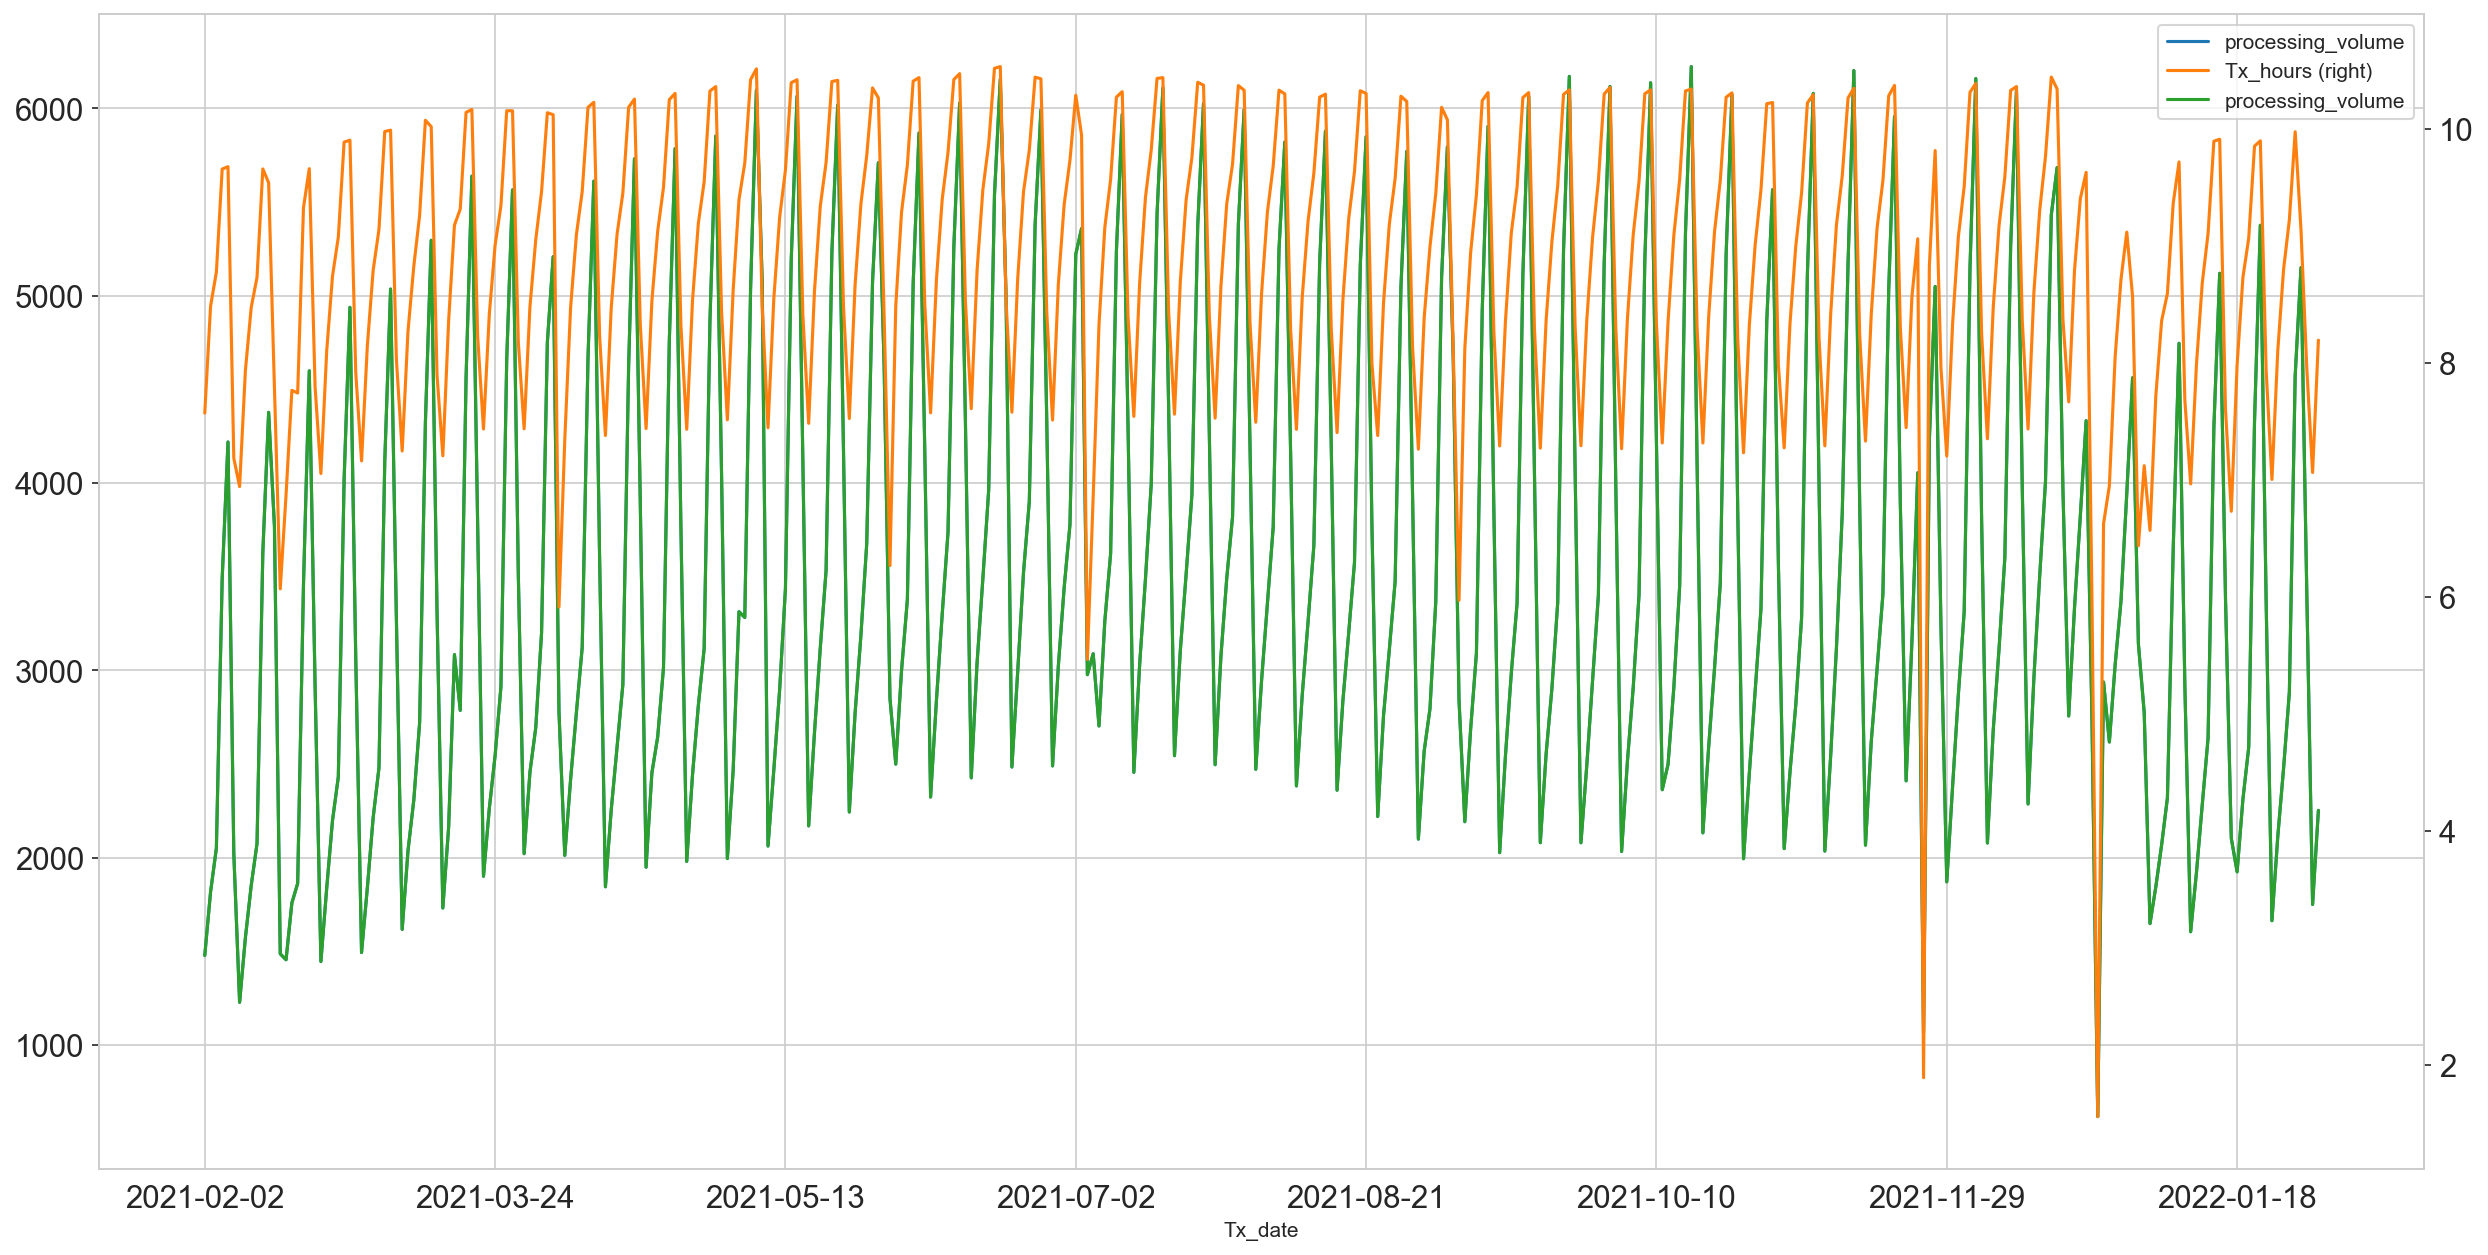

In [7]:
pivot_table = pd.pivot_table(df_train_tx, values=['processing_volume','Tx_hours'],index='Tx_date',aggfunc='mean')
fig, ax = plt.subplots(figsize=(20,10),dpi=150) 
pivot_table.plot( y = 'processing_volume', ax = ax,fontsize = "15")
pivot_table.plot( secondary_y = 'Tx_hours', ax = ax,fontsize = "15") 

In [8]:
def normalize_ownership_type(x):
    if x == 'SoleProprietorship': return 'Sole Proprietorship'
    elif x == 'PrivateCorporation': return 'Private Corporation'
    elif x == 'PublicCorporation': return 'Public Corporation'
    elif x == 'SECRegulatedCorporation': return 'SEC Regulated Corporation'
    elif x == 'NonProfit': return 'Non Profit'
    elif x == 'Corporate': return 'Corporation'
    else: return x

df_train_acc['Ownership_type'] = df_train_acc['Ownership_type'].apply(normalize_ownership_type)
df_holdout_acc['Ownership_type'] = df_holdout_acc['Ownership_type'].apply(normalize_ownership_type)

In [9]:
df_train_acc['Ownership_type'].value_counts()

Ownership_type
LLC                          5761
Corporation                  2318
Private Corporation           928
Partnership                   884
Sole Proprietorship           610
Public Corporation             39
Non Profit                     26
Other                          10
SEC Regulated Corporation       6
Government                      5
Franchise                       3
Financial Institution           1
Trust                           1
Name: count, dtype: int64

In [10]:
df_train_acc['Restaurant_cat'] = df_train_acc.Restaurant_catagory.str[:3]
df_holdout_acc['Restaurant_cat'] = df_holdout_acc.Restaurant_catagory.str[:3]

In [11]:
df = df_train_acc
df_unique_n = df.nunique(axis=0).to_frame().rename(columns={0:'unique_values'})
df_unique_n.reset_index(inplace=True)
df_unique_n = df_unique_n.rename(columns = {'index':'feature_name'})

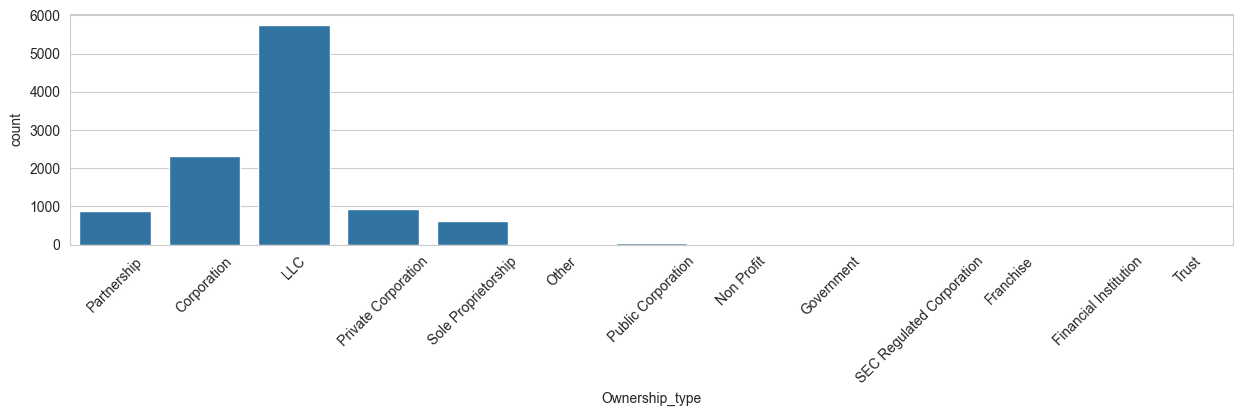

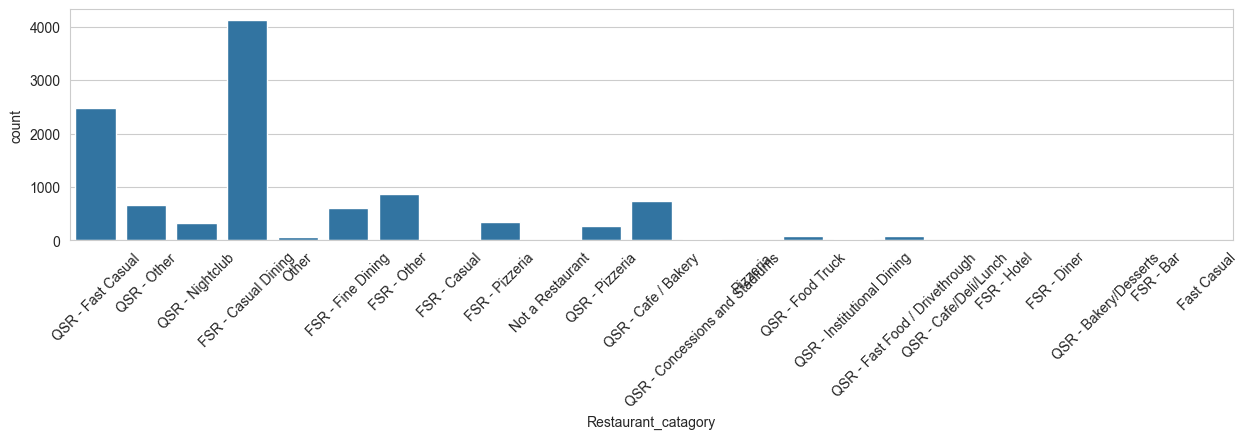

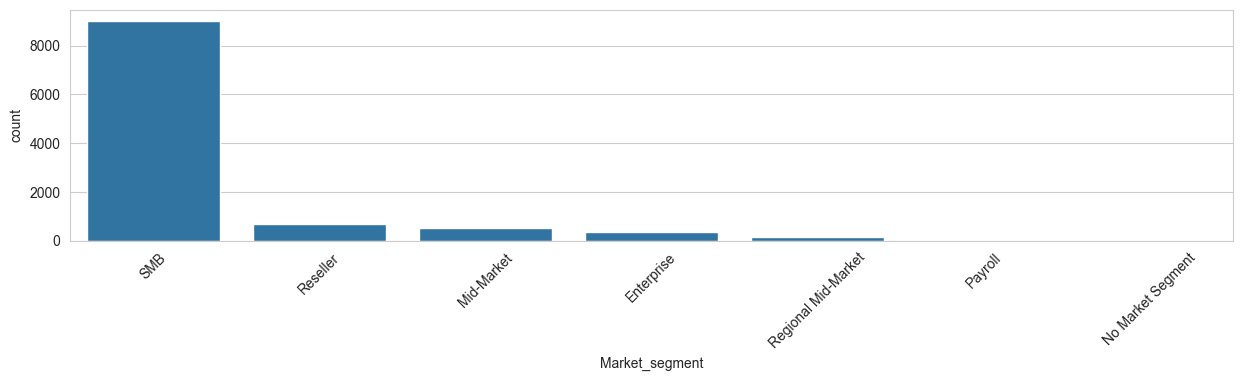

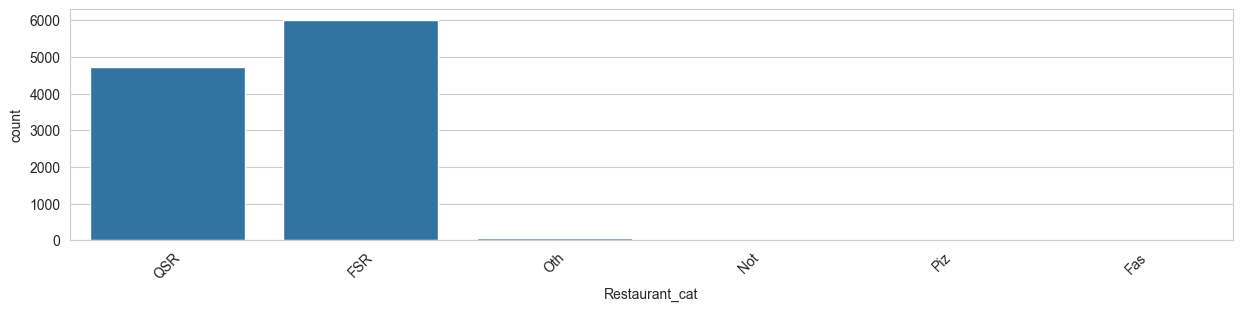

In [12]:
for col in list(df_unique_n[df_unique_n['unique_values']<=30].feature_name):
    plt.figure(figsize=(15,3))
    chart = sns.countplot(x=df[col])
    chart.set_xticklabels(chart.get_xticklabels(), rotation=45)

# Feature engineering

In [13]:
# Build rolling time-series features by Restaurant_ID and snapshot Tx_date
LABEL_KEY = 'Restaurant_ID'

def _build_timeseries_features(df_tx, windows=(7, 30, 90, 180)):
    df_work = df_tx[[LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours']].copy()
    df_work['Tx_date'] = pd.to_datetime(df_work['Tx_date'])
    df_work = df_work.sort_values([LABEL_KEY, 'Tx_date']).reset_index(drop=True)

    df_snapshots = (
        df_work[[LABEL_KEY, 'Tx_date']]
        .drop_duplicates([LABEL_KEY, 'Tx_date'])
        .copy()
    )

    for window in windows:
        df_window = (
            df_work
            .set_index('Tx_date')
            .groupby(LABEL_KEY)[['processing_volume', 'Tx_hours']]
            .rolling(f'{window}D', min_periods=1)
            .agg(['mean', 'min', 'max', 'std'])
            .reset_index()
        )

        df_window.columns = [
            LABEL_KEY, 'Tx_date',
            'avg_proc_vol', 'min_proc_vol', 'max_proc_vol', 'std_proc_vol',
            'avg_tx_hours', 'min_tx_hours', 'max_tx_hours', 'std_tx_hours'
        ]

        df_window[f'cv_proc_vol_{window}d'] = (
            df_window['std_proc_vol'] / df_window['avg_proc_vol'].replace(0, pd.NA)
        )
        df_window[f'cv_tx_hours_{window}d'] = (
            df_window['std_tx_hours'] / df_window['avg_tx_hours'].replace(0, pd.NA)
        )

        rename_map = {
            'avg_proc_vol': f'avg_proc_vol_{window}d',
            'min_proc_vol': f'min_proc_vol_{window}d',
            'max_proc_vol': f'max_proc_vol_{window}d',
            'avg_tx_hours': f'avg_tx_hours_{window}d',
            'min_tx_hours': f'min_tx_hours_{window}d',
            'max_tx_hours': f'max_tx_hours_{window}d',
        }

        keep_cols = [LABEL_KEY, 'Tx_date'] + list(rename_map.keys()) + [
            f'cv_proc_vol_{window}d',
            f'cv_tx_hours_{window}d',
        ]

        df_window = df_window[keep_cols].rename(columns=rename_map)
        df_snapshots = df_snapshots.merge(df_window, on=[LABEL_KEY, 'Tx_date'], how='left')

    # Momentum features: percent change vs exact lag date (current vs N days ago).
    df_daily = (
        df_work[[LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours']]
        .drop_duplicates([LABEL_KEY, 'Tx_date'])
        .rename(columns={
            'processing_volume': 'curr_processing_volume',
            'Tx_hours': 'curr_tx_hours',
        })
    )
    df_snapshots = df_snapshots.merge(df_daily, on=[LABEL_KEY, 'Tx_date'], how='left')

    for lag_days in windows:
        lag_df = df_daily.rename(columns={
            'curr_processing_volume': f'proc_vol_{lag_days}d_ago',
            'curr_tx_hours': f'tx_hours_{lag_days}d_ago',
        }).copy()
        lag_df['Tx_date'] = lag_df['Tx_date'] + pd.Timedelta(days=lag_days)

        df_snapshots = df_snapshots.merge(
            lag_df,
            on=[LABEL_KEY, 'Tx_date'],
            how='left',
        )

        df_snapshots[f'pct_change_proc_vol_vs_{lag_days}d_ago'] = (
            (df_snapshots['curr_processing_volume'] - df_snapshots[f'proc_vol_{lag_days}d_ago'])
            / df_snapshots[f'proc_vol_{lag_days}d_ago'].replace(0, pd.NA)
        )
        df_snapshots[f'pct_change_tx_hours_vs_{lag_days}d_ago'] = (
            (df_snapshots['curr_tx_hours'] - df_snapshots[f'tx_hours_{lag_days}d_ago'])
            / df_snapshots[f'tx_hours_{lag_days}d_ago'].replace(0, pd.NA)
        )

    df_snapshots['snapshot_day_of_week'] = df_snapshots['Tx_date'].dt.dayofweek
    df_snapshots['snapshot_day_of_year'] = df_snapshots['Tx_date'].dt.dayofyear
    df_snapshots['snapshot_month'] = df_snapshots['Tx_date'].dt.month
    df_snapshots['snapshot_quarter'] = df_snapshots['Tx_date'].dt.quarter

    return df_snapshots.sort_values([LABEL_KEY, 'Tx_date']).reset_index(drop=True)


df_train_features = _build_timeseries_features(df_train_tx)
df_holdoutfeatures = _build_timeseries_features(df_holdout_tx)

# Remove source file index artifacts before merge (avoids Unnamed: 0_x / Unnamed: 0_y).
df_train_acc_clean = df_train_acc.drop(columns=[c for c in df_train_acc.columns if c.startswith('Unnamed:')], errors='ignore')
df_train_label_clean = df_train_label.drop(columns=[c for c in df_train_label.columns if c.startswith('Unnamed:')], errors='ignore')
df_holdout_acc_clean = df_holdout_acc.drop(columns=[c for c in df_holdout_acc.columns if c.startswith('Unnamed:')], errors='ignore')

# Merge requested datasets
# train = account + features + labels
# holdout = account + features
df_train_merged = (
    df_train_features
    .merge(df_train_acc_clean, on=LABEL_KEY, how='left')
    .merge(df_train_label_clean, on=LABEL_KEY, how='left')
)
df_holdout_merged = df_holdoutfeatures.merge(df_holdout_acc_clean, on=LABEL_KEY, how='left')

print('df_train_features shape:', df_train_features.shape)
print('df_holdoutfeatures shape:', df_holdoutfeatures.shape)
print('df_train_merged shape:', df_train_merged.shape)
print('df_holdout_merged shape:', df_holdout_merged.shape)
print('Any Unnamed columns (train)?', any(c.startswith('Unnamed:') for c in df_train_merged.columns))
print('Any Unnamed columns (holdout)?', any(c.startswith('Unnamed:') for c in df_holdout_merged.columns))

df_train_features shape: (3510679, 56)
df_holdoutfeatures shape: (1471016, 56)
df_train_merged shape: (3510679, 61)
df_holdout_merged shape: (1471016, 60)
Any Unnamed columns (train)? False
Any Unnamed columns (holdout)? False
